# 03. M3 results: the experiment ladder

This notebook reads the results of `scripts/ml_m3.py` and walks through them (`context/ml-m3-method.md`, sections 2, 6, and 7). It covers:

1. The ladder: what each feature adds on top of Elo, scored on the same 3,450 development games.
2. Picking the final model with the one-standard-error rule.
3. The chosen model's coefficients, read as plain sentences.
4. Calibration.
5. What the quarterback news is worth (A4s against A4bs).
6. The holdout sign-off.

It reads saved files only, so run `python scripts/ml_m3.py` first if `data/raw/ml/m3/` is empty. Sections 1 to 5 use the development seasons only. Section 6 reads the single pre-registered holdout run (2020 to 2025) from the experiment registry.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "nflelo").is_dir())
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nflelo.ml import data as D, registry
from nflelo.ml.eval import calibration, bootstrap

plt.rcParams.update({"figure.figsize": (9, 3.6), "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "font.size": 10})
pd.set_option("display.width", 160)
INK, ACCENT, MUTED, BAD = "#1f2a44", "#2f6fdf", "#9aa3b2", "#d1495b"

frame = pd.read_parquet(D.ML_DIR / "m3" / "ladder_frame.parquet")
coefs = pd.read_parquet(D.ML_DIR / "m3" / "coefs.parquet")
dev = frame[frame["dev"]].copy()
runs = {}
for r in registry.load_runs():                      # newest run per ladder step
    if r["label"] == "dev" and r["name"].startswith("m3_A"):
        runs[r["name"][3:]] = r
print(f"{len(dev):,} development games (REG 2006-2019 with moneylines); {len(frame):,} REG games 2001-2019 in the frame.")

3,450 development games (REG 2006-2019 with moneylines); 4,856 REG games 2001-2019 in the frame.


## 1. The ladder

Every step is a logistic regression (A6 is boosted trees) refit once per season on all earlier regular-season games from 2001, with older seasons down-weighted (half-life 8 seasons). Features are computed as of the start of each game's week. The steps:

- **A0**: Elo's log-odds alone. This is the plumbing test: it should reproduce Elo.
- **A1**: plus the raw EPA margin from M1.
- **A2**: plus the opponent-adjusted EPA margin (notebook 02).
- **A3**: plus separate pass and rush margins instead of A2's combined one.
- **A4**: the better of A2/A3, plus the QB adjustment for each side, using the actual starter.
- **A4s**: the same, but with one symmetric QB term, `qb_delta_diff` = home QB delta minus away QB delta (three features).
- **A4b** and **A4bs**: A4 and A4s, but assuming last game's starter (what is known on Wednesday).
- **A5**: A4 plus rest difference and neutral site.
- **A6**: boosted trees on the A5 features, with monotonic constraints.

`vs Elo` is the model's Brier minus Elo's on the same games, with a 95% paired bootstrap interval. Negative is better.

In [2]:
rows = []
for step in ["A0", "A1", "A2", "A3", "A4", "A4s", "A4b", "A4bs", "A5", "A6"]:
    r = runs[step]; m = r["metrics"]; c = r["comparisons"]["vs_elo_brier"]
    rows.append({"step": step, "features": ", ".join(r["features"]).replace("_delta", ""),
                 "brier": m["brier"], "logloss": m["logloss"], "acc": m["accuracy"], "ece": m["ece"],
                 "vs Elo": c["diff"], "CI low": c["ci_low"], "CI high": c["ci_high"],
                 "within 1 SE": r["one_se"]["within"], "chosen": r["one_se"]["chosen"]})
ladder = pd.DataFrame(rows).set_index("step")
elo = {"brier": ((dev["y"] - dev["p_elo_v2"]) ** 2).mean(), "market": ((dev["y"] - dev["bench_market"]) ** 2).mean()}
print(f"Elo v2 Brier {elo['brier']:.4f}   market (benchmark) {elo['market']:.4f}")
ladder.style.format({"brier": "{:.4f}", "logloss": "{:.4f}", "acc": "{:.3f}", "ece": "{:.4f}",
                     "vs Elo": "{:+.4f}", "CI low": "{:+.4f}", "CI high": "{:+.4f}"})

Elo v2 Brier 0.2178   market (benchmark) 0.2106


,features,brier,logloss,acc,ece,vs Elo,CI low,CI high,within 1 SE,chosen
step,,,,,,,,,,
A0,elo_logit,0.2178,0.6257,0.645,0.0175,+0.0000,-0.0003,+0.0003,False,False
A1,"elo_logit, raw_epa_margin",0.2180,0.6260,0.645,0.0165,+0.0001,-0.0002,+0.0005,False,False
A2,"elo_logit, adj_epa_margin",0.2177,0.6254,0.644,0.0124,-0.0002,-0.0008,+0.0005,False,False
A3,"elo_logit, adj_pass_margin, adj_rush_margin",0.2180,0.6262,0.639,0.0157,+0.0002,-0.0006,+0.0010,False,False
A4,"elo_logit, adj_epa_margin, qb_home, qb_away",0.2150,0.6195,0.647,0.0125,-0.0028,-0.0045,-0.0011,True,False
A4s,"elo_logit, adj_epa_margin, qb_diff",0.2151,0.6197,0.647,0.0114,-0.0027,-0.0043,-0.0011,True,True
A4b,"elo_logit, adj_epa_margin, qb_last_home, qb_last_away",0.2171,0.6244,0.647,0.0111,-0.0007,-0.0018,+0.0005,False,False
A4bs,"elo_logit, adj_epa_margin, qb_last_diff",0.2172,0.6244,0.643,0.0116,-0.0006,-0.0016,+0.0004,False,False
A5,"elo_logit, adj_epa_margin, qb_home, qb_away, rest_diff, neutral",0.2150,0.6194,0.650,0.0087,-0.0028,-0.0046,-0.0011,True,False


How to read it:

- **A0 reproduces Elo** almost exactly, so the training pipeline is sound.
- **Team efficiency adds very little on top of Elo.** Raw EPA (A1) adds nothing, and the opponent-adjusted margin (A2) helps by only 0.0002, inside the noise. Splitting pass and rush (A3) is slightly worse. Elo already knows how good teams are; season-long efficiency mostly repeats it. (The two are correlated about 0.9.)
- **The quarterback is where the gain is.** A4 and A4s improve on Elo by about 0.003 Brier, and the intervals exclude zero. That closes roughly 40% of the gap between Elo (0.2178) and the market (0.2106). One symmetric QB term (A4s) does as well as separate home and away terms (A4).
- **Rest and neutral site (A5)** add nothing measurable to Brier, though they improve calibration a little.
- **Boosted trees (A6)** do worse than the logistic model with the same features. With about 4,500 training games, the flexible model mostly fits noise.
- Nothing scored below 0.213, the level where we agreed to suspect a leak.

## 2. Picking the final model: the one-standard-error rule

The best development Brier is A5's, but A4 and A4s are within a hair of it. Small edges on the development seasons often come from noise, and the holdout punishes complexity bought with noise. So the rule (decision M3-D3) is: among the steps whose Brier is within one standard error of the best, take the simplest. The standard error here is the paired bootstrap standard error of each step's Brier minus the best step's, over the same games.

In [3]:
best = next(s for s, r in runs.items() if r["comparisons"]["vs_best_brier"]["diff"] == 0)
t = pd.DataFrame({s: {"Brier minus best": r["comparisons"]["vs_best_brier"]["diff"],
                      "one SE": r["comparisons"]["vs_best_brier"]["boot_se"],
                      "features": len(r["features"]), "within": r["one_se"]["within"]}
                  for s, r in runs.items()}).T.loc[["A0", "A1", "A2", "A3", "A4", "A4s", "A4b", "A4bs", "A5", "A6"]]
chosen = next(s for s, r in runs.items() if r["one_se"]["chosen"])
print(f"Best: {best}. Within one SE: {list(t.index[t['within'].astype(bool)])}. Chosen (simplest of those): {chosen}")
t.style.format({"Brier minus best": "{:+.5f}", "one SE": "{:.5f}"})

Best: A5. Within one SE: ['A4', 'A4s', 'A5']. Chosen (simplest of those): A4s


,Brier minus best,one SE,features,within
A0,+0.00284,0.00086,1,False
A1,+0.00297,0.00086,2,False
A2,+0.00267,0.00080,2,False
A3,+0.00303,0.00084,3,False
A4,+0.00001,0.00029,4,True
A4s,+0.00010,0.00032,3,True
A4b,+0.00216,0.00072,4,False
A4bs,+0.00219,0.00069,3,False
A5,+0.00000,0.00000,6,True
A6,+0.00225,0.00081,6,False


A4s is chosen: three features (Elo, the adjusted EPA margin, and one symmetric QB term), logistic regression. It is 0.0001 behind A5, against a standard error of 0.0003.

It meets the M3 bar on the development window: it beats Elo with a 95% interval that excludes zero, and its calibration error is under 0.02.

## 3. The coefficients, in plain English

The model is refit every season. Below are the coefficients of the 2019 fit (trained on 2001 to 2018), with the range over all 14 development refits. Every refit has the expected sign for every feature.

In [4]:
c = coefs[coefs["step"] == chosen].set_index("season")
feats = runs[chosen]["features"]
show = pd.DataFrame({"2019 fit": c.loc[2019, ["intercept", *feats]],
                     "min (2006-2019)": c[["intercept", *feats]].min(),
                     "max (2006-2019)": c[["intercept", *feats]].max()})
show.round(3)

,2019 fit,min (2006-2019),max (2006-2019)
intercept,0.048,0.021,0.091
elo_logit,0.842,0.619,0.871
adj_epa_margin,1.087,0.872,2.214
qb_delta_diff,3.607,2.740,3.759


In [5]:
b = c.loc[2019]
logit = lambda p: np.log(p / (1 - p))
prob = lambda z: 1 / (1 + np.exp(-z))
p0 = 0.60
print(f"Start from a game Elo calls {p0:.0%} for the home team (log-odds {logit(p0):+.2f}).")
print(f"1. Elo: the model keeps {b['elo_logit']:.2f} of Elo's log-odds, so on its own it would say "
      f"{prob(b['intercept'] + b['elo_logit'] * logit(p0)):.1%}. Elo is slightly overconfident once the other features are in.")
z = b["intercept"] + b["elo_logit"] * logit(p0)
print(f"2. Matchup: a home edge of +0.10 EPA per play in the adjusted matchup adds {b['adj_epa_margin'] * 0.10:+.3f} "
      f"log-odds: {prob(z):.1%} -> {prob(z + b['adj_epa_margin'] * 0.10):.1%}.")
print(f"3. Home QB: if the home starter is 0.15 EPA per dropback worse than the QB play the team's rating remembers "
      f"(a typical backup), qb_delta_diff is -0.15: {b['qb_delta_diff'] * -0.15:+.2f} log-odds, {prob(z):.1%} -> {prob(z + b['qb_delta_diff'] * -0.15):.1%}.")
print(f"4. Away QB: the same backup on the road makes qb_delta_diff +0.15: {b['qb_delta_diff'] * 0.15:+.2f} log-odds, "
      f"{prob(z):.1%} -> {prob(z + b['qb_delta_diff'] * 0.15):.1%}. By construction, the two sides are worth the same.")
print(f"5. The intercept, {b['intercept']:+.3f}, is a small extra home edge; most of home field is already inside Elo's log-odds.")

Start from a game Elo calls 60% for the home team (log-odds +0.41).
1. Elo: the model keeps 0.84 of Elo's log-odds, so on its own it would say 59.6%. Elo is slightly overconfident once the other features are in.
2. Matchup: a home edge of +0.10 EPA per play in the adjusted matchup adds +0.109 log-odds: 59.6% -> 62.2%.
3. Home QB: if the home starter is 0.15 EPA per dropback worse than the QB play the team's rating remembers (a typical backup), qb_delta_diff is -0.15: -0.54 log-odds, 59.6% -> 46.2%.
4. Away QB: the same backup on the road makes qb_delta_diff +0.15: +0.54 log-odds, 59.6% -> 71.7%. By construction, the two sides are worth the same.
5. The intercept, +0.048, is a small extra home edge; most of home field is already inside Elo's log-odds.


Two things worth noticing:

- **Elo's weight is below 1** (about 0.84). Once the model knows about QB changes, it trusts Elo a bit less, because some of Elo's confident calls were about teams that were about to start a backup.
- **One QB coefficient for both sides.** The first version (A4) gave each side its own coefficient, and the home one came out about twice the away one (2019 fit: +4.74 vs -2.31). The next section checks whether that was a bug or the data.

Elo and the EPA margin are correlated about 0.9, so their separate coefficients should be read with care (spec section 7). The QB term is nearly uncorrelated with both, which is why its coefficient is stable and easy to read.

### Why A4's home and away QB coefficients differed

If the asymmetry were a bug, the two deltas would look different, or the starter IDs would be attached to the wrong side. Neither is the case:

In [6]:
rows = {}
for side in ("home", "away"):
    x, xl = dev[f"qb_delta_{side}"], dev[f"qb_last_delta_{side}"]
    big = x < -0.1
    rows[side] = {"mean": x.mean(), "SD": x.std(), "share nonzero": (x.abs() > 1e-12).mean(),
                  "share starter changed": (x != xl).mean(), "games with delta < -0.1": int(big.sum()),
                  "  home win rate": dev.loc[big, "y"].mean(), "  A2 (no QB) predicted": dev.loc[big, "p_A2"].mean(),
                  "  market": dev.loc[big, "bench_market"].mean()}
pd.DataFrame(rows).round(3)

,home,away
mean,0.001,0.002
SD,0.046,0.043
share nonzero,0.907,0.902
share starter changed,0.105,0.102
games with delta < -0.1,128.000,127.000
home win rate,0.348,0.669
A2 (no QB) predicted,0.589,0.578
market,0.465,0.678


In [7]:
# Are the schedule's starter IDs attached to the right side? Compare with each side's main passer in the play-by-play.
from nflelo.teams import franchise
sch = D.load_schedules(range(2006, 2020)).set_index("game_id")
db = D.load_pbp(range(2006, 2020), columns=["game_id", "posteam", "passer_id", "qb_dropback"])
db = db[db["qb_dropback"] == 1].join(sch[["season", "home_team"]], on="game_id")
db["side"] = np.where([franchise(p, int(y)) == franchise(h, int(y)) for p, h, y in zip(db["posteam"], db["home_team"], db["season"])],
                      "home", "away")
main = db.groupby(["game_id", "side"])["passer_id"].agg(lambda v: v.value_counts().index[0]).unstack()
g = sch.loc[main.index]
print(f"home_qb_id is the home team's main passer in {(g['home_qb_id'] == main['home']).mean():.1%} of games, "
      f"the away team's in {(g['home_qb_id'] == main['away']).mean():.1%}")
print(f"away_qb_id is the away team's main passer in {(g['away_qb_id'] == main['away']).mean():.1%} of games, "
      f"the home team's in {(g['away_qb_id'] == main['home']).mean():.1%}")

home_qb_id is the home team's main passer in 97.0% of games, the away team's in 0.0%
away_qb_id is the away team's main passer in 97.7% of games, the home team's in 0.0%


- The two deltas have the same mean, spread, and share of starter changes, and the code computes both sides the same way: each side's own team's dropbacks feed its "remembered" QB value, and neutral sites don't enter the QB term. The starter IDs sit on the right side (the few misses are games where the starter left early and a backup threw more).
- The asymmetry is in the **outcomes**. When the home team starts a clearly worse QB (delta below -0.1), the home team won only about 35% of the time, against about 59% predicted without the QB term. That's a drop of about 24 points. When the away team does, the home team won about 67%, against 58% predicted, a gain of about 9 points.
- The **market**, which sees far more information than these outcomes, moves about the same amount either way (roughly 12 and 10 points). So the most likely explanation is noise in about 125 games per side, not a real home/away effect.

So it's data, not a bug. The symmetric term (A4s) costs only 0.0001 Brier against A4 (95% interval includes zero), uses one fewer coefficient, and can't overfit this noise. That makes it the safer choice for the holdout.

## 4. Calibration

When the chosen model says 70%, does the home team win about 70% of the time? Points on the diagonal are perfectly calibrated.

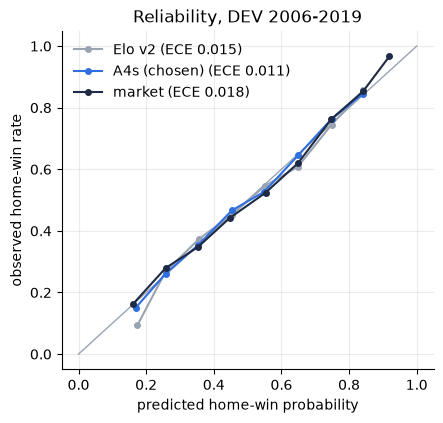

In [8]:
fig, ax = plt.subplots(figsize=(4.8, 4.4))
ax.plot([0, 1], [0, 1], color=MUTED, lw=1)
for name, col, color in [("Elo v2", "p_elo_v2", MUTED), (f"{chosen} (chosen)", f"p_{chosen}", ACCENT), ("market", "bench_market", INK)]:
    t = calibration.reliability_table(dev["y"], dev[col], bins=10)
    t = t[t["n"] >= 30]
    ax.plot(t["mean_pred"], t["observed"], "o-", ms=4, color=color,
            label=f"{name} (ECE {calibration.ece(dev['y'], dev[col]):.3f})")
ax.set_xlabel("predicted home-win probability"); ax.set_ylabel("observed home-win rate")
ax.set_title("Reliability, DEV 2006-2019"); ax.legend(frameon=False, loc="upper left"); plt.show()

All three sit close to the diagonal. The chosen model's calibration error (about 0.011) is lower than Elo's (0.015), well under the 0.02 bar.

## 5. What the QB news is worth: A4s against A4bs

Decision M3-D1 treats the starting QB's identity as known before kickoff (the market prices it, and the live site would refresh predictions once starters are announced). A4bs is the strict alternative: assume last game's starter. The difference between them is the value of knowing who actually starts.

In [9]:
changed = (dev["qb_delta_home"] != dev["qb_last_delta_home"]) | (dev["qb_delta_away"] != dev["qb_last_delta_away"])
def brier(x, col): return ((x["y"] - x[col]) ** 2).mean()
rows = []
for label, m in [("starter differs from last game", changed), ("same starters as last game", ~changed), ("all", changed | ~changed)]:
    x = dev[m]
    rows.append({"games": int(m.sum()), "Elo": brier(x, "p_elo_v2"), "A2": brier(x, "p_A2"),
                 "A4s (actual starter)": brier(x, "p_A4s"), "A4bs (last starter)": brier(x, "p_A4bs"),
                 "market": brier(x, "bench_market")})
ci = bootstrap.paired_bootstrap(dev["y"], dev["p_A4s"], dev["p_A4bs"], "brier")
print(f"A4s minus A4bs, all DEV games: {ci['diff']:+.4f} Brier, 95% CI [{ci['ci_low']:+.4f}, {ci['ci_high']:+.4f}]")
pd.DataFrame(rows, index=[r for r in ["starter differs from last game", "same starters as last game", "all"]]).round(4)

A4s minus A4bs, all DEV games: -0.0021 Brier, 95% CI [-0.0033, -0.0010]


,games,Elo,A2,A4s (actual starter),A4bs (last starter),market
starter differs from last game,664,0.2259,0.2252,0.2150,0.2256,0.2072
same starters as last game,2786,0.2159,0.2159,0.2151,0.2152,0.2114
all,3450,0.2178,0.2177,0.2151,0.2172,0.2106


The gain is almost entirely in the 664 games (about one in five) where a team's starter differs from its previous game. That includes every week 1, where "last game" means last season's finale. In those games, knowing the actual starter cuts the Brier from about 0.226 to 0.215. When the starter is unchanged, the two score about the same.

With only Wednesday information (A4bs), the QB adjustment is worth much less: about 0.0006 against Elo, and that interval includes zero. So **most of M3's gain depends on knowing who starts**. For the live site, that means predictions should be refreshed once starters are confirmed, and the Wednesday version should be labeled as provisional.

Here are the development games where the QB adjustment moved the home team's probability the most, with the actual result:

In [10]:
names = D.load_schedules(range(2006, 2020)).set_index("game_id")[["home_qb_name", "away_qb_name"]]
x = dev.set_index("game_id").join(names)
x["shift"] = x["p_A4s"] - x["p_A2"]
top = x.reindex(x["shift"].abs().sort_values(ascending=False).index).head(8)
pd.DataFrame({"home QB": top["home_qb_name"], "away QB": top["away_qb_name"],
              "QB delta home": top["qb_delta_home"].round(3), "QB delta away": top["qb_delta_away"].round(3),
              "A2 (no QB)": top["p_A2"].round(2), "A4s": top["p_A4s"].round(2), "market": top["bench_market"].round(2),
              "home won": top["y"]})

,home QB,away QB,QB delta home,QB delta away,A2 (no QB),A4s,market,home won
game_id,,,,,,,,
2009_17_NO_CAR,Matt Moore,Mark Brunell,0.113,-0.331,0.44,0.78,0.78,1.0
2019_08_GB_KC,Matt Moore,Aaron Rodgers,-0.361,0.003,0.67,0.35,0.32,0.0
2009_12_ARI_TEN,Vince Young,Matt Leinart,0.132,-0.239,0.51,0.79,0.64,1.0
2008_08_TB_DAL,Brad Johnson,Jeff Garcia,-0.289,0.077,0.58,0.30,0.54,1.0
2011_17_DET_GB,Matt Flynn,Matthew Stafford,-0.419,0.019,0.77,0.50,0.29,1.0
2013_10_PHI_GB,Seneca Wallace,Nick Foles,-0.340,0.047,0.77,0.52,0.48,0.0
2017_17_SF_LA,Sean Mannion,Jimmy Garoppolo,-0.154,0.221,0.83,0.58,0.29,0.0
2019_09_MIN_KC,Matt Moore,Kirk Cousins,-0.262,0.000,0.55,0.32,0.33,1.0


## What to take away

- **M3 passes on the development window.** The chosen model (A4s: Elo, adjusted EPA margin, and one symmetric QB term) beats Elo by about 0.003 Brier, with a 95% interval that excludes zero and a calibration error near 0.011. That is about 40% of the way from Elo to the market.
- **The quarterback is the signal.** Team efficiency, raw or adjusted, adds almost nothing once Elo is in the model. The QB adjustment is what moves the needle, and most of it comes from knowing the actual starter.
- **Simple won.** Boosted trees did worse, and the one-SE rule picked the three-feature logistic over the four-feature A4 and the six-feature A5.
- **The home/away QB asymmetry in A4 was noise in the outcomes, not a bug.** The symmetric term gives up essentially nothing.

**Holdout:** the pre-registered run is in section 6 below.

**Caveats:** Elo v2 was tuned on 1980 to 2009, so 2006 to 2009 are in-sample for Elo (this flatters Elo, not the model). nflfastR's EPA models were trained on data that includes later seasons, a limitation shared by all public EPA work. Boosted trees ran on scikit-learn's histogram GBM instead of LightGBM, because LightGBM's OpenMP library is missing on this machine; it's the same algorithm family with the same monotonic constraints.

## 6. Holdout sign-off (2020 to 2025)

Walker approved the one pre-registered holdout run on 2026-10-03. The frozen A4s model was scored once on every 2020 to 2025 regular-season game with a moneyline, using `python scripts/ml_m3.py --signoff`. Nothing about the model, features, or knobs changed, and the walk-forward was the same as on DEV: each season was fit on 2001 through the season before. This section only reads the logged runs; it does not recompute them.

In [11]:
so = {}
for r in registry.load_runs():                      # newest sign-off run per model
    if r["label"] == "holdout" and r["name"].startswith("m3_signoff_"):
        so[r["name"][len("m3_signoff_"):]] = r
assert len({r["games_hash"] for r in so.values()}) == 1, "sign-off rows must be scored on identical games"
print(f"REG 2020-2025 games with moneylines: n = {so['A4s']['n']}, games hash {so['A4s']['games_hash'][:16]}, "
      f"holdout flag {so['A4s']['holdout']}")
pd.DataFrame({k: so[k]["metrics"] for k in ["A4s", "elo_v2", "market", "A4bs"]}).T[["brier", "logloss", "accuracy", "ece"]].round(4)

REG 2020-2025 games with moneylines: n = 1615, games hash 1b27abff81bddb2c, holdout flag True


,brier,logloss,accuracy,ece
A4s,0.2195,0.6310,0.6429,0.0283
elo_v2,0.2231,0.6392,0.6373,0.0402
market,0.2096,0.6081,0.6689,0.0250
A4bs,0.2216,0.6360,0.6373,0.0311


In [12]:
ci = so["A4s"]["comparisons"]
pd.DataFrame({k: {"diff": v["diff"], "95% CI low": v["ci_low"], "95% CI high": v["ci_high"], "excludes 0": v["excludes_zero"]}
              for k, v in ci.items()}).T.round(4)

,diff,95% CI low,95% CI high,excludes 0
A4s_minus_elo_brier,-0.003532,-0.006324,-0.000691,True
A4s_minus_elo_logloss,-0.008191,-0.01471,-0.001604,True
A4s_minus_market_brier,0.009885,0.006146,0.013708,True
A4s_minus_market_logloss,0.022902,0.014443,0.03138,True
A4s_minus_A4bs_brier,-0.002048,-0.004156,0.000181,False


Per season and by starter change. Both are descriptive only: the pre-registered test is the full-window comparison above.

In [13]:
per = pd.DataFrame(so["A4s"]["per_season"]).set_index("season")
per["A4s minus Elo"] = per["brier_A4s"] - per["brier_elo_v2"]
display(per.rename(columns={"brier_A4s": "A4s", "brier_elo_v2": "Elo", "brier_market": "market"}).round(4))
sp = so["A4s"]["starter_split"]
pd.DataFrame({k: {"games": v["n"], "A4s": v["brier_A4s"], "Elo": v["brier_elo"], "A4s minus Elo": v["diff"],
                  "CI low": v["ci_low"], "CI high": v["ci_high"], "A4bs": v["brier_A4bs"], "market": v["brier_market"]}
              for k, v in sp.items()}).T.round(4)

,n,A4s,Elo,market,A4s minus Elo
season,,,,,
2020,256,0.2125,0.2155,0.2011,-0.0030
2021,272,0.2244,0.2308,0.2163,-0.0064
2022,271,0.2200,0.2232,0.2095,-0.0032
2023,272,0.2334,0.2337,0.2187,-0.0003
2024,272,0.2072,0.2124,0.2002,-0.0052
2025,272,0.2192,0.2223,0.2116,-0.0030


,games,A4s,Elo,A4s minus Elo,CI low,CI high,A4bs,market
changed,374.0,0.2190,0.2266,-0.0076,-0.0156,0.0011,0.2269,0.1994
unchanged,1241.0,0.2197,0.2220,-0.0023,-0.0048,0.0002,0.2200,0.2127


### What the holdout says

- **A4s beats Elo out of sample.** Brier 0.2195 against 0.2231, a difference of -0.0035 with a 95% interval of [-0.0063, -0.0007], which excludes zero. Log loss agrees. A4s beats Elo in all six seasons, though by only 0.0003 in 2023.
- **It misses the calibration bar.** A4s's ECE is 0.028, above the 0.02 bar that M3 used on DEV. Elo (0.040) and the market (0.025) are also above it on this window. Read strictly, the M3 bar (beat Elo with an interval excluding zero, and ECE under 0.02) is **not met**, because of calibration.
- **But ECE is noisy at this sample size.** The next cell simulates a model that is perfectly calibrated by construction: it draws 1,615 predictions from A4s's own DEV predictions and draws outcomes from those probabilities. Its ECE has a median of about 0.024, and 0.028 is well inside the usual range. So the holdout gives no clear evidence that A4s is miscalibrated. The 0.02 bar was too tight for 1,615 games; that is worth fixing in the M4 plan, not by changing this verdict.
- **The market is still well ahead:** A4s minus market is +0.0099 [+0.0061, +0.0137], wider than on DEV (+0.0045). The market scored about the same as on DEV (0.2096 vs 0.2106), while A4s and Elo both did worse (0.2195 and 0.2231, against 0.2151 and 0.2178).
- **The QB news effect shrank:** A4s minus A4bs is -0.0020 with an interval of [-0.0042, +0.0002] that now includes zero. On DEV it was -0.0021 and excluded zero. Starter changes were rarer here (374 of 1,615 games, 23%). The A4s-minus-Elo gain on those games is -0.0076 against -0.0023 on unchanged games, and both intervals include zero once split.

This result is recorded as it is. Per the pre-registration, there is no retuning on the holdout.

In [14]:
# ECE of a perfectly calibrated model: predictions resampled from A4s on DEV (no holdout data), outcomes drawn from them.
rng = np.random.default_rng(20261003)
p_dev = dev["p_A4s"].to_numpy()
sims = {}
for n in (1615, 3450):
    e = []
    for _ in range(500):
        q = rng.choice(p_dev, n)
        e.append(calibration.ece((rng.uniform(size=n) < q).astype(float), q))
    sims[n] = np.percentile(e, [5, 50, 95])
pd.DataFrame(sims, index=["5th pct", "median", "95th pct"]).T.rename_axis("games").round(4)

,5th pct,median,95th pct
games,,,
1615,0.0144,0.0243,0.0379
3450,0.0093,0.0169,0.0256
